In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('/home/fverdian/class/soundspeed-scripts/kernels-fullnum/UV_counterterm_Pcc')
from num_kernels2 import NumKernels, PLfromClass
import vegas

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern"],
})


In [16]:
fx=0.00001
t_ini = -6
fullt=np.linspace(t_ini,1, 200)
teval=0
kref=1.
supprshift=2
nk = NumKernels(fx=fx, kref=kref, fullt=fullt, rtol=0.01)


In [17]:
kp= 5
qp = 300
x = (qp/kp)**2
def F3_UV_mu(mup):
    F3_c, _, _, _ =nk.solve_F3([kp,qp,mup])
    return F3_c*x

def F3_EdS_mu(mup):
    return nk.F3_0(kp,qp,mup)*x

muev = 1.
print(-1/6,-1/6+1/9*fx)

print(F3_EdS_mu(muev))
print(F3_UV_mu(muev))
print(5/63,5/63-71/1890*fx)


-0.16666666666666666 -0.16666555555555554
-0.16666666666666666
0.016666666666666666 0.016666666666666666 -0.016949152542372878 -0.00014124293785310732
-0.166666646481913
0.07936507936507936 0.0793647037037037


In [18]:
mup=1. #MUST EVALUATE IT AT mu=0, otherwise the eds has a divergence
qp=10
klist=np.logspace(-3,0,10)
F3list_low=[]
for kp in klist:
    print(f'k={kp:.1e}', end='\r', flush=True)
    x = (qp/kp)**2
    _,_,F3c,_=nk.solve_F3([kp,qp,mup], return_timedep=False)
    F3list_low.append([F3c*x,nk.F3_0(kp,qp,mup)*x])
F3list_low=np.array(F3list_low).T;


0.0001 0.0001 -0.00010001000100010003 -5.000500050005001e-09
0.00021544346900318848 0.00021544346900318848 -0.0002154898948936795 -2.3212945245513393e-08
0.00046415888336127773 0.00046415888336127773 -0.00046437442687671836 -1.0777175772031545e-07
0.001 0.001 -0.001001001001001001 -5.005005005005005e-07
0.0021544346900318834 0.0021544346900318834 -0.0021590863004563596 -2.3258052122378914e-06
0.004641588833612777 0.004641588833612777 -0.004663233646836461 -1.0822406611841754e-05
0.009999999999999998 0.009999999999999998 -0.0101010101010101 -5.050505050505049e-05
0.021544346900318822 0.021544346900318822 -0.02201872597093981 -0.00023718953531049332
0.04641588833612777 0.04641588833612777 -0.04867519054521417 -0.0011296511045432015
0.1 0.1 -0.11111111111111112 -0.005555555555555557


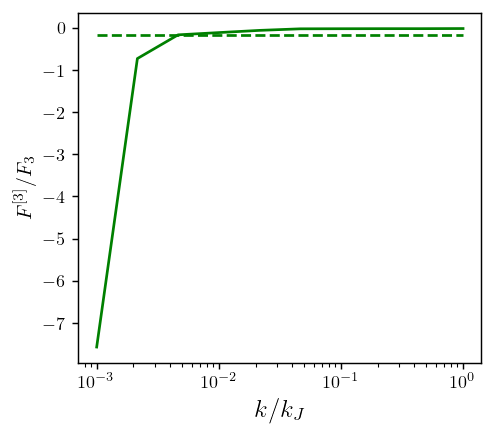

In [19]:
plt.figure(figsize=(4, 3.5), dpi=130)

plt.plot(klist,F3list_low[0], 'g', label=r'$F_\chi^{[3]}$ num')
plt.plot(klist,F3list_low[1], 'g--', label=r'$F_\chi^{[3]}$ num')

# plt.axhline(1., color='k', linestyle=':', linewidth=0.7)

plt.ylabel(r'$F^{[3]}/F_3$', fontsize=11)
plt.xscale('log')
# plt.yscale('symlog')

plt.xlabel(r'$k/k_J$', fontsize=14)
# plt.savefig('/home/fverdian/class/soundspeed-scripts/figure/F3chi_limB.pdf', bbox_inches='tight')

plt.show()

----
Now integrate in $\mu$

In [25]:
integ = vegas.Integrator([0., 1.],mpi=True, nproc=72)
result_EdS = integ(F3_EdS_mu,neval=1000)

result = integ(F3_UV_mu,neval=50)


In [27]:
print(result_EdS, -0.0322751)

print(result)

-0.0322678(94) -0.0322751
-0.02965(84)


In [19]:
# Expected values

# k << kJ
print(-61/1890 + fx* 286/14175)

# k >> kJ
print(-61/1890 + fx* 488/99225)

-0.030257495590828926
-0.03178332073570169


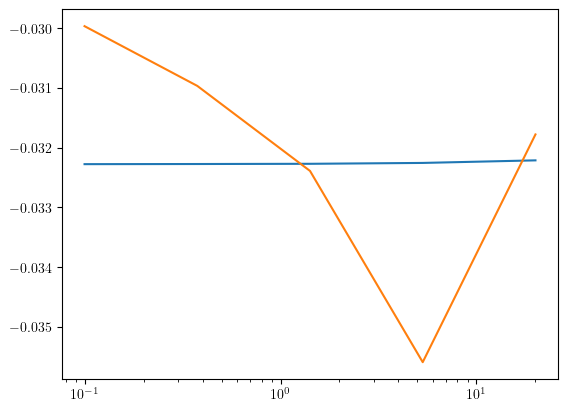

In [102]:
kval, eds, num = np.loadtxt('/home/fverdian/class/soundspeed-scripts/kernels-fullnum/UV_counterterm_Pcc/int.txt', unpack=True)

plt.plot(kval, eds)
plt.plot(kval, num)
plt.xscale('log')
plt.show()